In [1]:
%pip install mlflow scikit-learn pandas -q


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import mlflow
import mlflow.sklearn

In [5]:
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.shape)
print(data.target_names)
X.head()

(178, 13)
['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [6]:
print(X.describe())
print(y.value_counts())

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

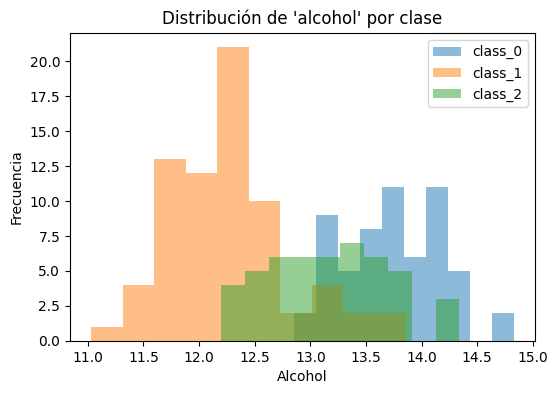

In [7]:
plt.figure(figsize=(6,4))
for target_value in y.unique():
    subset = X[y == target_value]
    plt.hist(subset["alcohol"], alpha=0.5, label=data.target_names[target_value])
plt.xlabel("Alcohol")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de 'alcohol' por clase")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(142, 13) (36, 13)


In [9]:
mlflow.set_experiment("clasificacion_vino")

n_estimators = 100
max_depth = 5

with mlflow.start_run(run_name="random_forest_wine"):

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=data.target_names))

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("model_type", "RandomForestClassifier")

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1_score", f1)

    mlflow.sklearn.log_model(model, "modelo_random_forest")

    print(mlflow.active_run().info.run_id)

2026/07/20 13:57:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

043d45db0e7c4dd7b6dfe1c3a4c721cb


In [10]:
fastapi_code = """
from fastapi import FastAPI, Query
from transformers import pipeline

app = FastAPI(title="Mi API de Practica - FastAPI + Hugging Face")

sentiment_pipeline = pipeline("sentiment-analysis")
summarization_pipeline = pipeline("summarization")


@app.get("/")
def read_root():
    return {"mensaje": "Bienvenido a mi API de practica con FastAPI y Hugging Face"}


@app.get("/health")
def health_check():
    return {"status": "ok"}


@app.get("/sentiment")
def analyze_sentiment(text: str = Query(...)):
    result = sentiment_pipeline(text)
    return {"input": text, "result": result}


@app.get("/summarize")
def summarize_text(text: str = Query(...)):
    result = summarization_pipeline(text, max_length=60, min_length=10, do_sample=False)
    return {"input": text, "summary": result}


@app.get("/info")
def get_info():
    return {
        "nombre": "Practica FastAPI + HuggingFace",
        "endpoints": ["/", "/health", "/sentiment", "/summarize", "/info"]
    }
"""

print(fastapi_code)


from fastapi import FastAPI, Query
from transformers import pipeline

app = FastAPI(title="Mi API de Practica - FastAPI + Hugging Face")

sentiment_pipeline = pipeline("sentiment-analysis")
summarization_pipeline = pipeline("summarization")


@app.get("/")
def read_root():
    return {"mensaje": "Bienvenido a mi API de practica con FastAPI y Hugging Face"}


@app.get("/health")
def health_check():
    return {"status": "ok"}


@app.get("/sentiment")
def analyze_sentiment(text: str = Query(...)):
    result = sentiment_pipeline(text)
    return {"input": text, "result": result}


@app.get("/summarize")
def summarize_text(text: str = Query(...)):
    result = summarization_pipeline(text, max_length=60, min_length=10, do_sample=False)
    return {"input": text, "summary": result}


@app.get("/info")
def get_info():
    return {
        "nombre": "Practica FastAPI + HuggingFace",
        "endpoints": ["/", "/health", "/sentiment", "/summarize", "/info"]
    }

